# Identificação de gênero em Calopsitas
#### Ana Laura Siqueira Mendes

Este notebook tem por objetivo comparar as arquiteturas de redes neurais convolucionais **ResNet50** e **EfficientNet-B0** na classificação de gênero em calopsita atraés de estratégias de *transfer learning* no contexto de problemas *few-shot*. 

Ambas serão utilizadas como backbone forte para extração de características visuais gerais, enquanto uma cabeça de classificação é responsável por aprender a classificação das calopsitas entre machos e fêmeas. 

Por se tratar de um problema *few-shot*, em ambos os experimentos o *dataset* passa por tratamentos de *data augmentation* a fim de aumentar a diversidade e quantidade de informações para treino.

## Bibliotecas

In [23]:
%pip install Augmentor

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import numpy as np
import pandas as pd

import tensorflow as tf

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

import matplotlib.pyplot as plt

import os
import zipfile

import gdown
import Augmentor

## Download e tratamento do *dataset*

### Download do dataset - GDrive

In [25]:
dataset_url = "https://drive.google.com/uc?id=1b8v5Pak9sEkxCa3Ta9HnW47aaPR__-Gi"
dataset_root = "cockatiel_gender_segmented"
dataset_zip = "cockatiel_gender_segmented.zip"

if not os.path.exists(dataset_root):
    gdown.download(dataset_url, dataset_zip, quiet=False, fuzzy=True)
    with zipfile.ZipFile(dataset_zip, "r") as zip_ref:
        zip_ref.extractall(".")
    os.remove(dataset_zip)
else:
    print(f"Dataset already available at ./{dataset_root}")

Downloading...
From (original): https://drive.google.com/uc?id=1b8v5Pak9sEkxCa3Ta9HnW47aaPR__-Gi
From (redirected): https://drive.google.com/uc?id=1b8v5Pak9sEkxCa3Ta9HnW47aaPR__-Gi&confirm=t&uuid=c871994d-076f-4aaf-806c-0eb63fda4efa
To: c:\Users\anala\Documents\UFOP\cockatiel-gender-identification-cnn\cockatiel_gender_segmented.zip
100%|██████████| 33.1M/33.1M [00:01<00:00, 23.7MB/s]


### Data Augmentation 

Configura operações do **Augmentor** para gerar novas variações das imagens de treino e aumentar a diversidade do conjunto de dados.

#### Operações aplicadas

- **Rotação** (`rotate`)
    - Rotaciona a imagem em até **25° para a esquerda ou para a direita**.
    - **Probabilidade:** 70%
    - Ajuda o modelo a lidar com diferentes ângulos de captura.

- **Zoom aleatório** (`zoom_random`)
    - Aplica um zoom com **80% da área original**.
    - **Probabilidade:** 50%
    - Simula aproximações e pequenas variações no enquadramento.

- **Espelhamento horizontal** (`flip_left_right`)
    - Inverte a imagem da esquerda para a direita.
    - **Probabilidade:** 50%
    - **Escala de cinza** (`greyscale`)
        - Converte a imagem para tons de cinza.
        - **Probabilidade:** 30%
        - Ajuda o modelo a focar em forma e textura independentemente da cor.

    - **Ajuste aleatório de cor** (`random_color`)
        - Ajusta a intensidade das cores multiplicativamente entre **1.2** e **1.8**.
        - **Probabilidade:** 50%
        - Simula variações de iluminação e saturação, tornando o modelo mais robusto a mudanças de cor.

    - **Amostragem final** (`sample`)
        - Gera um número definido de imagens aumentadas no diretório de saída (parâmetro `num_samples`).
        - No notebook usamos `num_samples=1000` para expandir o conjunto de treino.

In [26]:
def data_augmentation(input_path, output_path, num_samples):
  pipeline = Augmentor.Pipeline(input_path, output_directory=output_path)

  pipeline.resize(probability=1.0, width=512, height=512)
  pipeline.rotate_without_crop(
      probability=0.7,
      max_left_rotation=25,
      max_right_rotation=25,
      fillcolor=(255, 255, 255)
  )
  pipeline.zoom_random(probability=0.5, percentage_area=0.8)
  pipeline.flip_left_right(probability=0.5)
  pipeline.greyscale(probability=0.3)
  pipeline.random_color(probability=0.5, min_factor=1.2, max_factor=1.8)
  pipeline.sample(num_samples)


Aplicação das operações do augmentator nos dados de treino

In [27]:
dataset_root = "cockatiel_gender_segmented"

input_path_train = os.path.join(dataset_root, "cockatiel_gender_train")
output_path_train = "cockatiel_gender_augmented"

if not os.path.exists(os.path.join(input_path_train, output_path_train)):
    data_augmentation(input_path_train, output_path_train, 1000)
else:
    print(f"Augmentação já existe em {os.path.join(input_path_train, output_path_train)}")


Initialised with 113 image(s) found.
Output directory set to cockatiel_gender_segmented\cockatiel_gender_train\cockatiel_gender_augmented.

Processing <PIL.Image.Image image mode=RGB size=512x512 at 0x196F0E25730>: 100%|██████████| 1000/1000 [00:37<00:00, 26.91 Samples/s] 


In [28]:
datagen = ImageDataGenerator(rescale=1./255)

base_dir_train = os.path.join(dataset_root, "cockatiel_gender_train", output_path_train)

train_generator = datagen.flow_from_directory(
    base_dir_train,
    target_size=(224, 224),
    batch_size=64,
    class_mode='binary',
)

base_dir_validation = os.path.join(dataset_root, "cockatiel_gender_validation")

validation_generator = datagen.flow_from_directory(
    base_dir_validation,
    target_size=(224, 224),
    batch_size=64,
    class_mode='binary',
    shuffle=False,
)

base_dir_test = os.path.join(dataset_root, "cockatiel_gender_test")

test_generator = datagen.flow_from_directory(
    base_dir_test,
    target_size=(224, 224),
    batch_size=64,
    class_mode='binary',
    shuffle=False,
)


Found 1000 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
Found 23 images belonging to 2 classes.


In [29]:
class_counts = np.bincount(train_generator.classes)
class_weights = {
    index: class_counts.sum() / (len(class_counts) * count)
    for index, count in enumerate(class_counts)
}

class_names_by_index = {index: name for name, index in train_generator.class_indices.items()}
print('Distribuição das classes:', {class_names_by_index[i]: int(count) for i, count in enumerate(class_counts)})
print('Class weights:', class_weights)


Distribuição das classes: {'female': 487, 'male': 513}
Class weights: {0: 1.0266940451745379, 1: 0.9746588693957114}


#### Exemplos do dataset após augmentation


In [30]:
def plot_images(images, labels, class_names):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    plt.show()

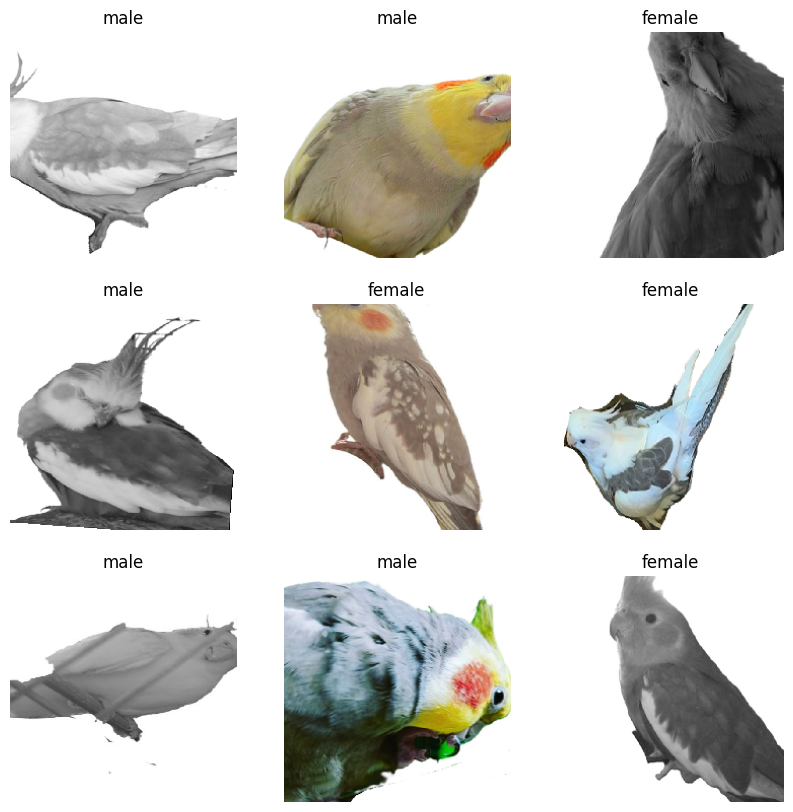

In [31]:
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

plot_images(images, labels, class_names)

## Experimento 0: ResNet 50

Treinamento inicial do classificador, fine tuning das últimas camadas da ResNet50 e avaliação final no conjunto de teste.

### 0.1. Classificador base

Neste bloco, montamos a ResNet50 congelada e treinamos apenas a cabeça de classificação inicial.

In [32]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    class_weight=class_weights
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_24     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,653,313 (90.23 MB)

 Trainable params: 65,601 (256.25 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.5117 - auc: 0.5149 - loss: 0.7678 - precision: 0.5279 - recall: 0.5283 - val_accuracy: 0.4348 - val_auc: 0.6154 - val_loss: 0.7279 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5353 - auc: 0.5431 - loss: 0.7060 - precision: 0.5533 - recall: 0.4411 - val_accuracy: 0.5652 - val_auc: 0.6923 - val_loss: 0.6792 - val_precision: 0.5652 - val_recall: 1.0000
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5300 - auc: 0.5464 - loss: 0.6929 - precision: 0.5422 - recall: 0.5631 - val_accuracy: 0.4348 - val_auc: 0.6615 - val_loss: 0.7007 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5398 - auc: 0.5630 - loss: 0.6875 - precision: 0.5701 - recall: 0.3580 - val_accuracy: 0.5652 - val_auc: 0.6731 - val_loss: 0.6764 - val_precision: 0.5652 - val_recall: 1.0000
Epoch 5/10
16/16 ━━━━━━━

### 0.2. Fine tuning e limiar de decisão

Aqui liberamos parte do backbone, refinamos o treinamento e estimamos o melhor limiar usando a validação.

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.4915 - auc: 0.5613 - loss: 1.8694 - precision: 0.4915 - recall: 1.0000 - val_accuracy: 0.7391 - val_auc: 0.6923 - val_loss: 0.6681 - val_precision: 0.7059 - val_recall: 0.9231
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.5340 - auc: 0.6665 - loss: 0.7598 - precision: 0.5281 - recall: 0.9788 - val_accuracy: 0.6087 - val_auc: 0.7000 - val_loss: 0.6582 - val_precision: 0.5909 - val_recall: 1.0000
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.6235 - auc: 0.7411 - loss: 0.6162 - precision: 0.5933 - recall: 0.7955 - val_accuracy: 0.5652 - val_auc: 0.7038 - val_loss: 0.6517 - val_precision: 0.5652 - val_recall: 1.0000
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.6946 - auc: 0.7669 - loss: 0.5868 - precision: 0.7126 - recall: 0.6603 - val_accuracy: 0.5652 - val_auc: 0.7192 - val_loss: 0.6811 - val_precision: 0.5652 - val_recall: 1.0000
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 50

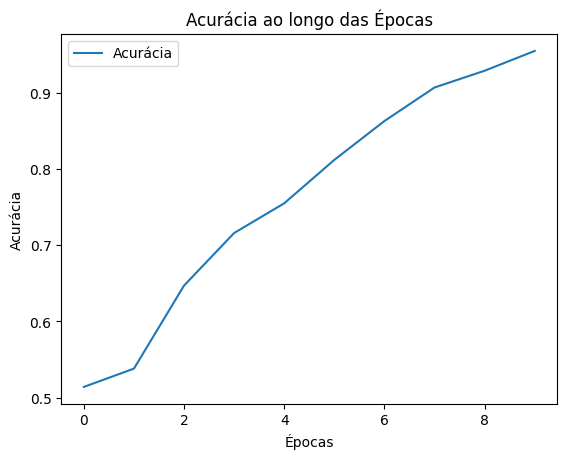

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Limiar ótimo na validação: 0.9801
F1 na validação: 0.7429


In [33]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

history_finetuning = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    class_weight=class_weights
)


def plot_acuracy(history):
    acc = history.history['accuracy']

    plt.plot(acc, label='Acurácia')
    plt.title('Acurácia ao longo das Épocas')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.show()


plot_acuracy(history_finetuning)
from sklearn.metrics import precision_recall_curve


def find_best_threshold(model, validation_generator):
    validation_generator.reset()
    validation_probabilities = model.predict(validation_generator).ravel()
    validation_true = validation_generator.classes

    precisions, recalls, thresholds = precision_recall_curve(validation_true, validation_probabilities)
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)

    best_index = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_index]
    best_f1 = f1_scores[best_index]

    print(f"Limiar ótimo na validação: {best_threshold:.4f}")
    print(f"F1 na validação: {best_f1:.4f}")

    return best_threshold


decision_threshold = find_best_threshold(model, validation_generator)

### 0.3. Avaliação no teste e predições

Por fim, avaliamos o modelo no teste e visualizamos algumas amostras previstas.

c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5652 - auc: 0.5500 - loss: 2.3146 - precision: 0.5652 - recall: 1.0000

Resultados:
loss: 2.3146
compile_metrics: 0.5652
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Limiar usado: 0.9801
Precisão (sklearn): 0.5455
Recall (sklearn): 0.9231
F1-score: 0.6857


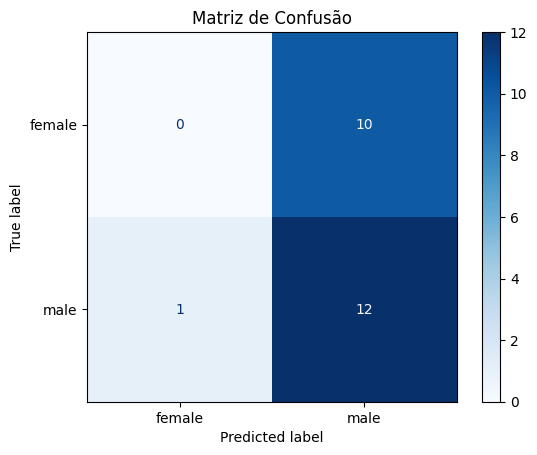

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


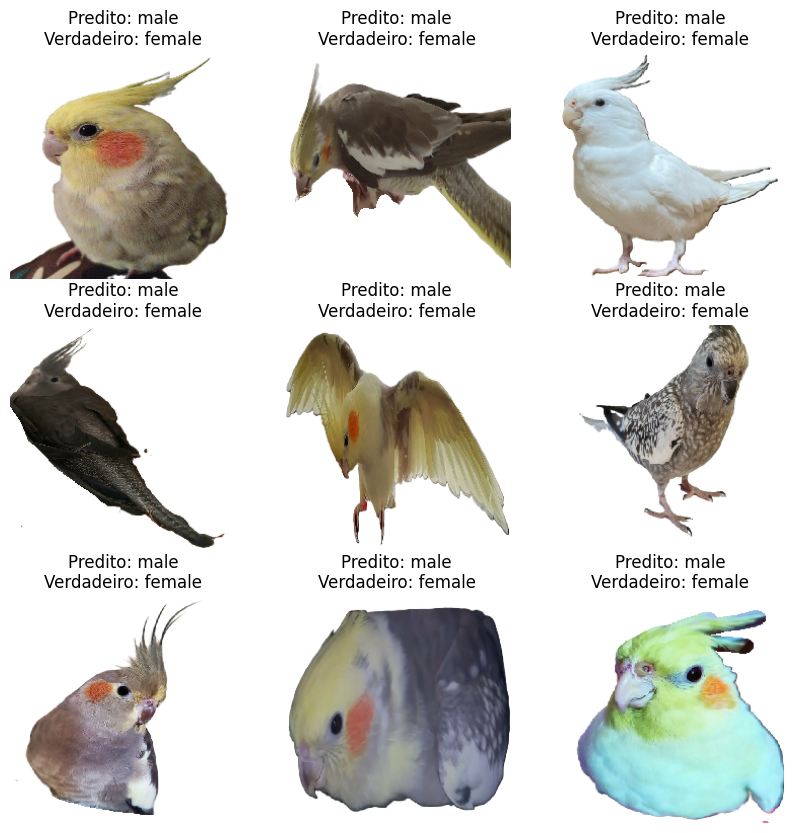

In [34]:
def evaluate_model(model, test_generator, threshold=0.5):

    test_generator.reset()
    results = model.evaluate(test_generator)

    metric_names = model.metrics_names

    print("\nResultados:")
    for name, value in zip(metric_names, results):
        print(f"{name}: {value:.4f}")

    test_generator.reset()
    predictions = model.predict(test_generator)

    predicted_classes = (predictions >= threshold).astype(int).flatten()

    precision = precision_score(test_generator.classes, predicted_classes)
    recall = recall_score(test_generator.classes, predicted_classes)
    f1 = f1_score(test_generator.classes, predicted_classes)

    print(f"\nLimiar usado: {threshold:.4f}")
    print(f"Precisão (sklearn): {precision:.4f}")
    print(f"Recall (sklearn): {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    cm = confusion_matrix(test_generator.classes, predicted_classes)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['female', 'male']
    )

    disp.plot(cmap=plt.cm.Blues)
    plt.title("Matriz de Confusão")
    plt.show()


evaluate_model(model, test_generator, threshold=decision_threshold)


def plot_predicted_images(model, test_generator, num_images=9, threshold=0.5):
    test_generator.reset()
    images, labels = next(test_generator)

    predictions = model.predict(images)

    class_names = list(test_generator.class_indices.keys())

    plt.figure(figsize=(10, 10))
    for i in range(min(num_images, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        predicted_label = class_names[int(predictions[i][0] >= threshold)]
        true_label = class_names[int(labels[i])]
        plt.title(f'Predito: {predicted_label}\nVerdadeiro: {true_label}')
        plt.axis("off")
    plt.show()


plot_predicted_images(model, test_generator, threshold=decision_threshold)

## Experimento 1: ResNet-50 e Cross Validation

Neste bloco, definimos os geradores de dados da ResNet50 e a arquitetura multiescala usada no experimento.

In [35]:
cv_train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.9, 1.1),
)

cv_eval_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)


def build_cv_multiscale_resnet50():
    inputs = layers.Input(shape=(224, 224, 3))

    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs,
    )
    base_model.trainable = False

    inter_features = base_model.get_layer('conv4_block6_out').output
    inter_pool = layers.GlobalAveragePooling2D()(inter_features)

    final_pool = layers.GlobalAveragePooling2D()(base_model.output)

    merged = layers.Concatenate()([inter_pool, final_pool])
    merged = layers.Dense(128, activation='relu')(merged)
    merged = layers.Dropout(0.4)(merged)
    outputs = layers.Dense(2, activation='softmax')(merged)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model, base_model

### 1.2. Treinamento por fold

Aqui aplicamos a validação cruzada estratificada em duas fases: primeiro com a base congelada e depois com fine-tuning parcial da ResNet.

In [36]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resnet_cv_results = []
resnet_oof_probabilities = np.zeros((len(cv_df), 2), dtype=np.float32)
resnet_phase1_epochs = []
resnet_phase2_epochs = []

for fold_number, (train_indices, val_indices) in enumerate(skf.split(cv_df['filepath'], cv_df['label_idx']), start=1):
    fold_train_df = cv_df.iloc[train_indices].reset_index(drop=True)
    fold_val_df = cv_df.iloc[val_indices].reset_index(drop=True)

    fold_train_generator = cv_train_datagen_resnet.flow_from_dataframe(
        fold_train_df,
        x_col='filepath',
        y_col='label',
        target_size=(224, 224),
        batch_size=32,
        class_mode='sparse',
        classes=cv_class_names,
        shuffle=True,
        seed=42,
    )

    fold_val_generator = cv_eval_datagen_resnet.flow_from_dataframe(
        fold_val_df,
        x_col='filepath',
        y_col='label',
        target_size=(224, 224),
        batch_size=32,
        class_mode='sparse',
        classes=cv_class_names,
        shuffle=False,
    )

    fold_model, fold_base_model = build_cv_multiscale_resnet50()

    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    fold_callbacks_phase1 = [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
    ]

    fold_history_phase1 = fold_model.fit(
        fold_train_generator,
        validation_data=fold_val_generator,
        epochs=15,
        callbacks=fold_callbacks_phase1,
        verbose=0,
    )

    fold_base_model.trainable = True
    for layer in fold_base_model.layers[:100]:
        layer.trainable = False

    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    fold_callbacks_phase2 = [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
    ]

    fold_history_phase2 = fold_model.fit(
        fold_train_generator,
        validation_data=fold_val_generator,
        epochs=30,
        callbacks=fold_callbacks_phase2,
        verbose=0,
    )

    fold_probabilities = fold_model.predict(fold_val_generator, verbose=0)
    fold_predictions = np.argmax(fold_probabilities, axis=1)
    resnet_oof_probabilities[val_indices] = fold_probabilities

    fold_true = fold_val_df['label_idx'].to_numpy()
    fold_accuracy = accuracy_score(fold_true, fold_predictions)
    fold_precision = precision_score(fold_true, fold_predictions, zero_division=0)
    fold_recall = recall_score(fold_true, fold_predictions, zero_division=0)
    fold_f1 = f1_score(fold_true, fold_predictions, zero_division=0)

    resnet_cv_results.append({
        'fold': fold_number,
        'accuracy': fold_accuracy,
        'precision': fold_precision,
        'recall': fold_recall,
        'f1': fold_f1,
        'phase1_epochs': len(fold_history_phase1.history['loss']),
        'phase2_epochs': len(fold_history_phase2.history['loss']),
    })

    resnet_phase1_epochs.append(len(fold_history_phase1.history['loss']))
    resnet_phase2_epochs.append(len(fold_history_phase2.history['loss']))

    print(
        f"Fold {fold_number}: accuracy={fold_accuracy:.4f}, "
        f"precision={fold_precision:.4f}, recall={fold_recall:.4f}, f1={fold_f1:.4f}"
    )

Found 108 validated image filenames belonging to 2 classes.
Found 28 validated image filenames belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Fold 1: accuracy=0.7500, precision=0.7500, recall=0.8000, f1=0.7742
Found 109 validated image filenames belonging to 2 classes.
Found 27 validated image filenames belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Fold 2: accuracy=0.6667, precision=0.6471, recall=0.7857, f1=0.7097
Found 109 validated image filenames belonging to 2 classes.
Found 27 validated image filenames belonging to 2 classes.


...

Fold 3: accuracy=0.7037, precision=0.7333, recall=0.7333, f1=0.7333
Found 109 validated image filenames belonging to 2 classes.
Found 27 validated image filenames belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Fold 4: accuracy=0.6296, precision=0.6471, recall=0.7333, f1=0.6875
Found 109 validated image filenames belonging to 2 classes.
Found 27 validated image filenames belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Fold 5: accuracy=0.8889, precision=0.9286, recall=0.8667, f1=0.8966


### 1.3. Resumo da cross validation

Aqui consolidamos as métricas dos folds e a matriz de confusão out-of-fold para avaliar a estabilidade do experimento.

      accuracy  precision    recall        f1
mean  0.727778   0.741204  0.783810  0.760251
std   0.100496   0.115079  0.055287  0.082685


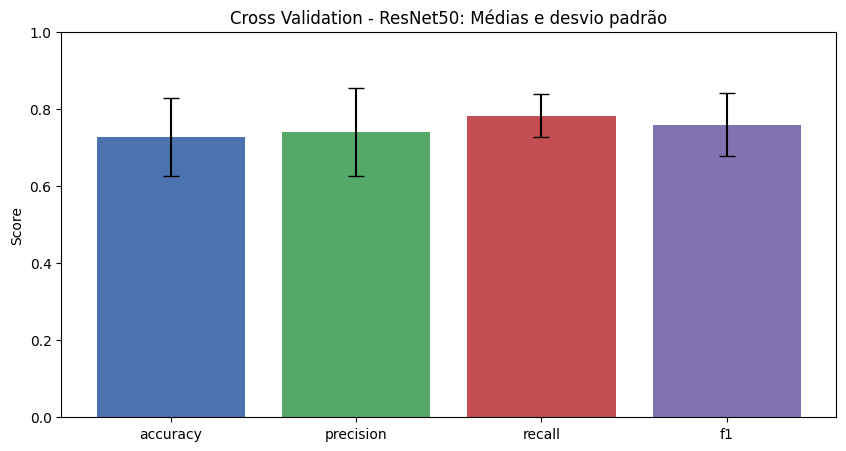

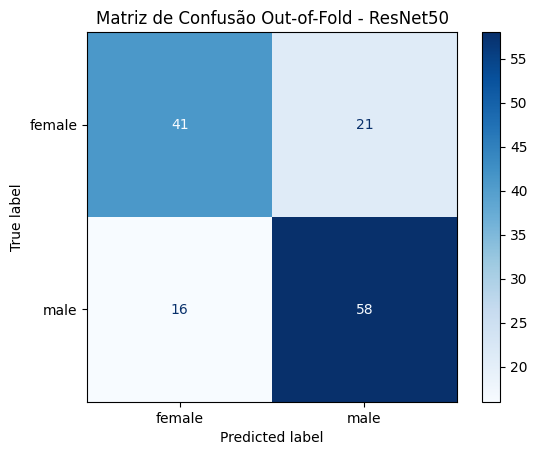

Resumo por fold:
   fold  accuracy  precision    recall        f1  phase1_epochs  phase2_epochs
0     1  0.750000   0.750000  0.800000  0.774194             13             19
1     2  0.666667   0.647059  0.785714  0.709677             13              5
2     3  0.703704   0.733333  0.733333  0.733333              6             30
3     4  0.629630   0.647059  0.733333  0.687500              8              5
4     5  0.888889   0.928571  0.866667  0.896552             15              5


In [37]:
resnet_cv_results_df = pd.DataFrame(resnet_cv_results)
print(resnet_cv_results_df[['accuracy', 'precision', 'recall', 'f1']].agg(['mean', 'std']))

plt.figure(figsize=(10, 5))
metric_names = ['accuracy', 'precision', 'recall', 'f1']
metric_means = [resnet_cv_results_df[name].mean() for name in metric_names]
metric_stds = [resnet_cv_results_df[name].std() for name in metric_names]

plt.bar(metric_names, metric_means, yerr=metric_stds, capsize=6, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Cross Validation - ResNet50: Médias e desvio padrão')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

resnet_oof_true_classes = cv_df['label_idx'].to_numpy()
resnet_oof_predicted_classes = np.argmax(resnet_oof_probabilities, axis=1)
resnet_oof_cm = confusion_matrix(resnet_oof_true_classes, resnet_oof_predicted_classes)
resnet_oof_disp = ConfusionMatrixDisplay(confusion_matrix=resnet_oof_cm, display_labels=cv_class_names)
resnet_oof_disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Out-of-Fold - ResNet50')
plt.show()

print('Resumo por fold:')
print(resnet_cv_results_df)

### 1.4. Treino final e avaliação no teste

Após a validação cruzada, treinamos um modelo final com todo o pool de treino+validação e avaliamos o desempenho no conjunto de teste separado.

Found 136 validated image filenames belonging to 2 classes.
Found 23 images belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5081 - loss: 1.3335
Epoch 2/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6645 - loss: 0.8176
Epoch 3/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6584 - loss: 0.6911
Epoch 4/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5976 - loss: 0.9433
Epoch 5/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6721 - loss: 0.5764
Epoch 6/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7588 - loss: 0.5222
Epoch 7/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7403 - loss: 0.4493
Epoch 8/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8119 - loss: 0.4459 
Epoch 9/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8069 - loss: 0.4157 
Epoch 10/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8524 - loss: 0.3682
Epoch 11/11
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7850 - loss: 0.3955
Epoch 1/13
5/5 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.8872 - loss: 0.3017
Epoch 2/13
5/5 ━━━━━

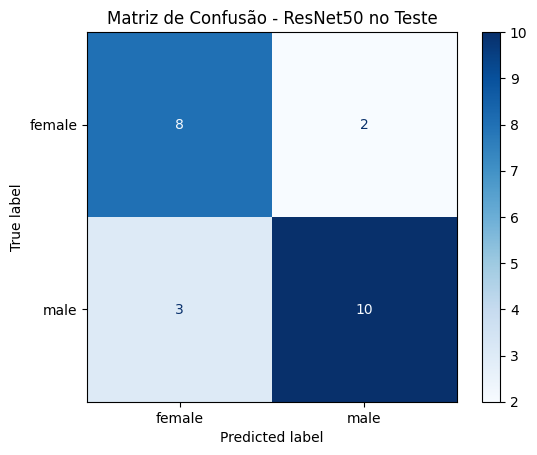

              precision    recall  f1-score   support

      female       0.73      0.80      0.76        10
        male       0.83      0.77      0.80        13

    accuracy                           0.78        23
   macro avg       0.78      0.78      0.78        23
weighted avg       0.79      0.78      0.78        23



In [44]:
final_resnet_pool_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.9, 1.1),
)

final_resnet_pool_generator = final_resnet_pool_datagen.flow_from_dataframe(
    cv_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    classes=cv_class_names,
    shuffle=True,
    seed=42,
)

final_resnet_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

final_resnet_test_generator = final_resnet_test_datagen.flow_from_directory(
    cv_segmented_test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    classes=cv_class_names,
    shuffle=False,
)

recommended_resnet_phase1_epochs = max(5, int(round(np.mean(resnet_phase1_epochs))))
recommended_resnet_phase2_epochs = max(5, int(round(np.mean(resnet_phase2_epochs))))

final_resnet_model, final_resnet_base_model = build_cv_multiscale_resnet50()
final_resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_resnet_model.fit(
    final_resnet_pool_generator,
    epochs=recommended_resnet_phase1_epochs,
    verbose=1,
)

final_resnet_base_model.trainable = True
for layer in final_resnet_base_model.layers[:100]:
    layer.trainable = False

final_resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_resnet_model.fit(
    final_resnet_pool_generator,
    epochs=recommended_resnet_phase2_epochs,
    verbose=1,
)

final_resnet_test_generator.reset()
final_resnet_test_probabilities = final_resnet_model.predict(final_resnet_test_generator, verbose=0)
final_resnet_test_predictions = np.argmax(final_resnet_test_probabilities, axis=1)
final_resnet_test_true = final_resnet_test_generator.classes

final_resnet_test_accuracy = accuracy_score(final_resnet_test_true, final_resnet_test_predictions)
final_resnet_test_precision = precision_score(final_resnet_test_true, final_resnet_test_predictions, zero_division=0)
final_resnet_test_recall = recall_score(final_resnet_test_true, final_resnet_test_predictions, zero_division=0)
final_resnet_test_f1 = f1_score(final_resnet_test_true, final_resnet_test_predictions, zero_division=0)

print(f'Acurácia no teste: {final_resnet_test_accuracy:.4f}')
print(f'Precisão no teste: {final_resnet_test_precision:.4f}')
print(f'Recall no teste: {final_resnet_test_recall:.4f}')
print(f'F1-score no teste: {final_resnet_test_f1:.4f}')

final_resnet_test_cm = confusion_matrix(final_resnet_test_true, final_resnet_test_predictions)
final_resnet_test_disp = ConfusionMatrixDisplay(confusion_matrix=final_resnet_test_cm, display_labels=cv_class_names)
final_resnet_test_disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - ResNet50 no Teste')
plt.show()

print(classification_report(final_resnet_test_true, final_resnet_test_predictions, target_names=cv_class_names, zero_division=0))

## Experimento 2: EfficientNet-B0


### 2.1. Base de dados da cross validation

O pool de cross validation é formado por treino e validação segmentados. As imagens do teste permanecem fora desta etapa.

In [39]:
cv_class_names = ['female', 'male']
cv_class_to_index = {name: index for index, name in enumerate(cv_class_names)}
cv_dataset_root = os.path.abspath('cockatiel_gender_segmented')
cv_segmented_train_path = os.path.join(cv_dataset_root, 'cockatiel_gender_train')
cv_segmented_validation_path = os.path.join(cv_dataset_root, 'cockatiel_gender_validation')
cv_segmented_test_path = os.path.join(cv_dataset_root, 'cockatiel_gender_test')
cv_pool_paths = [cv_segmented_train_path, cv_segmented_validation_path]


def build_image_dataframe(split_paths):
    rows = []
    for split_path in split_paths:
        for class_name in cv_class_names:
            class_dir = os.path.join(split_path, class_name)
            for filename in sorted(os.listdir(class_dir)):
                file_path = os.path.join(class_dir, filename)
                if os.path.isfile(file_path):
                    rows.append({
                        'filepath': file_path,
                        'label': class_name,
                        'label_idx': cv_class_to_index[class_name],
                    })
    return pd.DataFrame(rows)


cv_df = build_image_dataframe(cv_pool_paths)
print('Total de imagens para cross validation:', len(cv_df))
print(cv_df['label'].value_counts().to_dict())

Total de imagens para cross validation: 136
{'male': 74, 'female': 62}


### 2.2. Geradores e arquitetura do modelo

A validação cruzada usa augmentation apenas nos folds de treino e reutiliza a EfficientNet-B0 multiescala como backbone.

In [40]:
cv_train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.9, 1.1),
)

cv_eval_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
)


def build_cv_multiscale_efficientnet():
    inputs = layers.Input(shape=(224, 224, 3))

    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs,
    )
    base_model.trainable = False

    inter_features = base_model.get_layer('block5c_add').output
    inter_pool = layers.GlobalAveragePooling2D()(inter_features)

    final_pool = layers.GlobalAveragePooling2D()(base_model.output)

    merged = layers.Concatenate()([inter_pool, final_pool])
    merged = layers.Dense(128, activation='relu')(merged)
    merged = layers.Dropout(0.4)(merged)
    outputs = layers.Dense(2, activation='softmax')(merged)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model, base_model


### 2.3. Treinamento por fold

Cada fold treina o classificador em duas fases e registra métricas de validação para comparar a estabilidade do aprendizado.

In [41]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
oof_probabilities = np.zeros((len(cv_df), 2), dtype=np.float32)
cv_phase1_epochs = []
cv_phase2_epochs = []

for fold_number, (train_indices, val_indices) in enumerate(skf.split(cv_df['filepath'], cv_df['label_idx']), start=1):
    fold_train_df = cv_df.iloc[train_indices].reset_index(drop=True)
    fold_val_df = cv_df.iloc[val_indices].reset_index(drop=True)

    fold_train_generator = cv_train_datagen.flow_from_dataframe(
        fold_train_df,
        x_col='filepath',
        y_col='label',
        target_size=(224, 224),
        batch_size=32,
        class_mode='sparse',
        classes=cv_class_names,
        shuffle=True,
        seed=42,
    )

    fold_val_generator = cv_eval_datagen.flow_from_dataframe(
        fold_val_df,
        x_col='filepath',
        y_col='label',
        target_size=(224, 224),
        batch_size=32,
        class_mode='sparse',
        classes=cv_class_names,
        shuffle=False,
    )

    fold_model, fold_base_model = build_cv_multiscale_efficientnet()

    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    fold_callbacks_phase1 = [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
    ]

    fold_history_phase1 = fold_model.fit(
        fold_train_generator,
        validation_data=fold_val_generator,
        epochs=15,
        callbacks=fold_callbacks_phase1,
        verbose=0,
    )

    fold_base_model.trainable = True
    for layer in fold_base_model.layers[:100]:
        layer.trainable = False

    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    fold_callbacks_phase2 = [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
    ]

    fold_history_phase2 = fold_model.fit(
        fold_train_generator,
        validation_data=fold_val_generator,
        epochs=30,
        callbacks=fold_callbacks_phase2,
        verbose=0,
    )

    fold_probabilities = fold_model.predict(fold_val_generator, verbose=0)
    fold_predictions = np.argmax(fold_probabilities, axis=1)
    oof_probabilities[val_indices] = fold_probabilities

    fold_true = fold_val_df['label_idx'].to_numpy()
    fold_accuracy = accuracy_score(fold_true, fold_predictions)
    fold_precision = precision_score(fold_true, fold_predictions, zero_division=0)
    fold_recall = recall_score(fold_true, fold_predictions, zero_division=0)
    fold_f1 = f1_score(fold_true, fold_predictions, zero_division=0)

    cv_results.append({
        'fold': fold_number,
        'accuracy': fold_accuracy,
        'precision': fold_precision,
        'recall': fold_recall,
        'f1': fold_f1,
        'phase1_epochs': len(fold_history_phase1.history['loss']),
        'phase2_epochs': len(fold_history_phase2.history['loss']),
    })
    cv_phase1_epochs.append(len(fold_history_phase1.history['loss']))
    cv_phase2_epochs.append(len(fold_history_phase2.history['loss']))

    print(
        f"Fold {fold_number}: accuracy={fold_accuracy:.4f}, "
        f"precision={fold_precision:.4f}, recall={fold_recall:.4f}, f1={fold_f1:.4f}"
    )


Found 108 validated image filenames belonging to 2 classes.
Found 28 validated image filenames belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Fold 1: accuracy=0.8214, precision=0.7500, recall=1.0000, f1=0.8571
Found 109 validated image filenames belonging to 2 classes.
Found 27 validated image filenames belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Fold 2: accuracy=0.7037, precision=0.6875, recall=0.7857, f1=0.7333
Found 109 validated image filenames belonging to 2 classes.
Found 27 validated image filenames belonging to 2 classes.


...

Fold 3: accuracy=0.8148, precision=0.8571, recall=0.8000, f1=0.8276
Found 109 validated image filenames belonging to 2 classes.
Found 27 validated image filenames belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Fold 4: accuracy=0.5926, precision=0.6667, recall=0.5333, f1=0.5926
Found 109 validated image filenames belonging to 2 classes.
Found 27 validated image filenames belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Fold 5: accuracy=0.8519, precision=0.9231, recall=0.8000, f1=0.8571


### 2.4. Resumo da cross validation

Aqui consolidamos as métricas dos folds, além da matriz de confusão out-of-fold para enxergar o comportamento agregado do classificador.

      accuracy  precision    recall        f1
mean  0.756878   0.776877  0.783810  0.773560
std   0.107658   0.110311  0.165835  0.113202


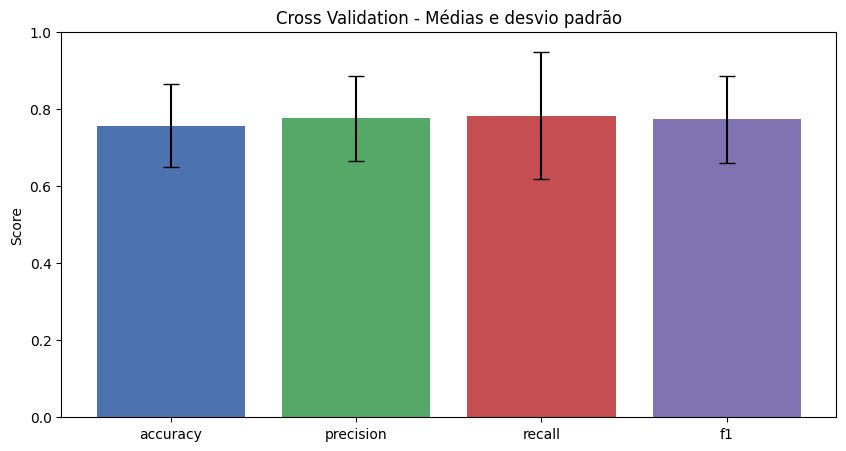

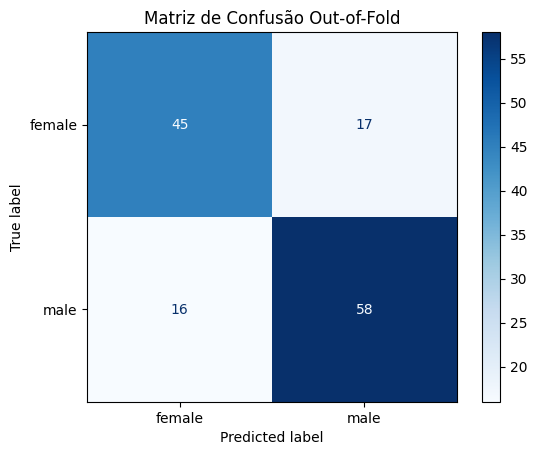

Resumo por fold:
   fold  accuracy  precision    recall        f1  phase1_epochs  phase2_epochs
0     1  0.821429   0.750000  1.000000  0.857143              7              5
1     2  0.703704   0.687500  0.785714  0.733333             11              5
2     3  0.814815   0.857143  0.800000  0.827586             14              5
3     4  0.592593   0.666667  0.533333  0.592593              6             26
4     5  0.851852   0.923077  0.800000  0.857143             13              5


In [42]:
cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df[['accuracy', 'precision', 'recall', 'f1']].agg(['mean', 'std']))

plt.figure(figsize=(10, 5))
metric_names = ['accuracy', 'precision', 'recall', 'f1']
metric_means = [cv_results_df[name].mean() for name in metric_names]
metric_stds = [cv_results_df[name].std() for name in metric_names]

plt.bar(metric_names, metric_means, yerr=metric_stds, capsize=6, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Cross Validation - Médias e desvio padrão')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

oof_true_classes = cv_df['label_idx'].to_numpy()
oof_predicted_classes = np.argmax(oof_probabilities, axis=1)
oof_cm = confusion_matrix(oof_true_classes, oof_predicted_classes)
oof_disp = ConfusionMatrixDisplay(confusion_matrix=oof_cm, display_labels=cv_class_names)
oof_disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Out-of-Fold')
plt.show()

print('Resumo por fold:')
print(cv_results_df)


### 2.5. Treino final e avaliação no teste

Depois de medir a estabilidade nos folds, treinamos um modelo final com todo o pool de treino+validação e só então avaliamos no conjunto de teste separado.

Found 136 validated image filenames belonging to 2 classes.
Found 23 images belonging to 2 classes.


c:\Users\anala\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 751ms/step - accuracy: 0.4315 - loss: 0.8363
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 789ms/step - accuracy: 0.7807 - loss: 0.5378
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 770ms/step - accuracy: 0.7694 - loss: 0.4520
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 895ms/step - accuracy: 0.8482 - loss: 0.3922
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 912ms/step - accuracy: 0.8612 - loss: 0.3195
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 697ms/step - accuracy: 0.9044 - loss: 0.2408
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 748ms/step - accuracy: 0.8545 - loss: 0.2926
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 705ms/step - accuracy: 0.8673 - loss: 0.2675
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 905ms/step - accuracy: 0.8756 - loss: 0.2375
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 719ms/step - accuracy: 0.9221 - loss: 0.2205
Epoch 1/9
5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8529 - loss: 0.3478
Epoch 2/9
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8906 - loss: 0.34

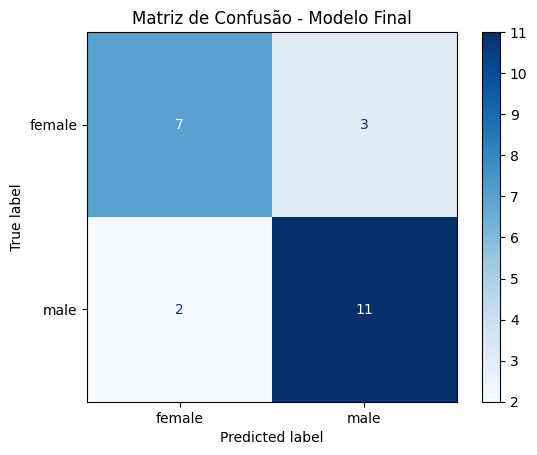

In [43]:
final_pool_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.9, 1.1),
)

final_pool_generator = final_pool_datagen.flow_from_dataframe(
    cv_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    classes=cv_class_names,
    shuffle=True,
    seed=42,
)

test_eval_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
)

test_eval_generator = test_eval_datagen.flow_from_directory(
    cv_segmented_test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    classes=cv_class_names,
    shuffle=False,
)

recommended_phase1_epochs = max(5, int(round(np.mean(cv_phase1_epochs))))
recommended_phase2_epochs = max(5, int(round(np.mean(cv_phase2_epochs))))

final_model, final_base_model = build_cv_multiscale_efficientnet()
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_model.fit(
    final_pool_generator,
    epochs=recommended_phase1_epochs,
    verbose=1,
)

final_base_model.trainable = True
for layer in final_base_model.layers[:100]:
    layer.trainable = False

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_model.fit(
    final_pool_generator,
    epochs=recommended_phase2_epochs,
    verbose=1,
)


test_eval_generator.reset()
final_test_probabilities = final_model.predict(test_eval_generator)
final_test_predictions = np.argmax(final_test_probabilities, axis=1)
final_test_true = test_eval_generator.classes

final_test_precision = precision_score(final_test_true, final_test_predictions)
final_test_recall = recall_score(final_test_true, final_test_predictions)
final_test_f1 = f1_score(final_test_true, final_test_predictions)

print(f'Precisão no teste: {final_test_precision:.4f}')
print(f'Recall no teste: {final_test_recall:.4f}')
print(f'F1-score no teste: {final_test_f1:.4f}')

final_test_cm = confusion_matrix(final_test_true, final_test_predictions)
final_test_disp = ConfusionMatrixDisplay(confusion_matrix=final_test_cm, display_labels=cv_class_names)
final_test_disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Modelo Final')
plt.show()
